[2026-08-05 22:44:42] [info     ] start inference                end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-08-05 22:44:42] [info     ] loaded ALSTM/LSTM 1m model     device=cuda epoch=4 loss=mse_ic n_features=25 path=/home/aiuser/work/lstm_best.json
[2026-08-05 22:44:42] [info     ] streaming prediction plan      date_blocks=2 instrument_blocks=7 instruments_per_block=200 months_per_block=6 total_blocks=14
[2026-08-05 22:44:42] [info     ] query bar data                 end='2024-06-30 23:59:59' features=25 instruments=100 start='2023-12-25 00:00:00' table=bigalpha_2026_stock_bar1m
[2026-08-05 22:44:49] [info     ] query done                     rows=2927520 seconds=6.83
[2026-08-05 22:44:52] [info     ] window build start             bars_per_day=240 instruments=100 mode=infer rows=2927520 seq_len=240
[2026-08-05 22:44:53] [info     ] window build progress          instruments_done=1 instruments_total=100 mode=infer samples=117
[2026-08-05 22:44:54] [info     ] windo

时段,IC
2024-01-15~2024-02-08,0.0101
2024-09-24~2024-10-08,0.0463

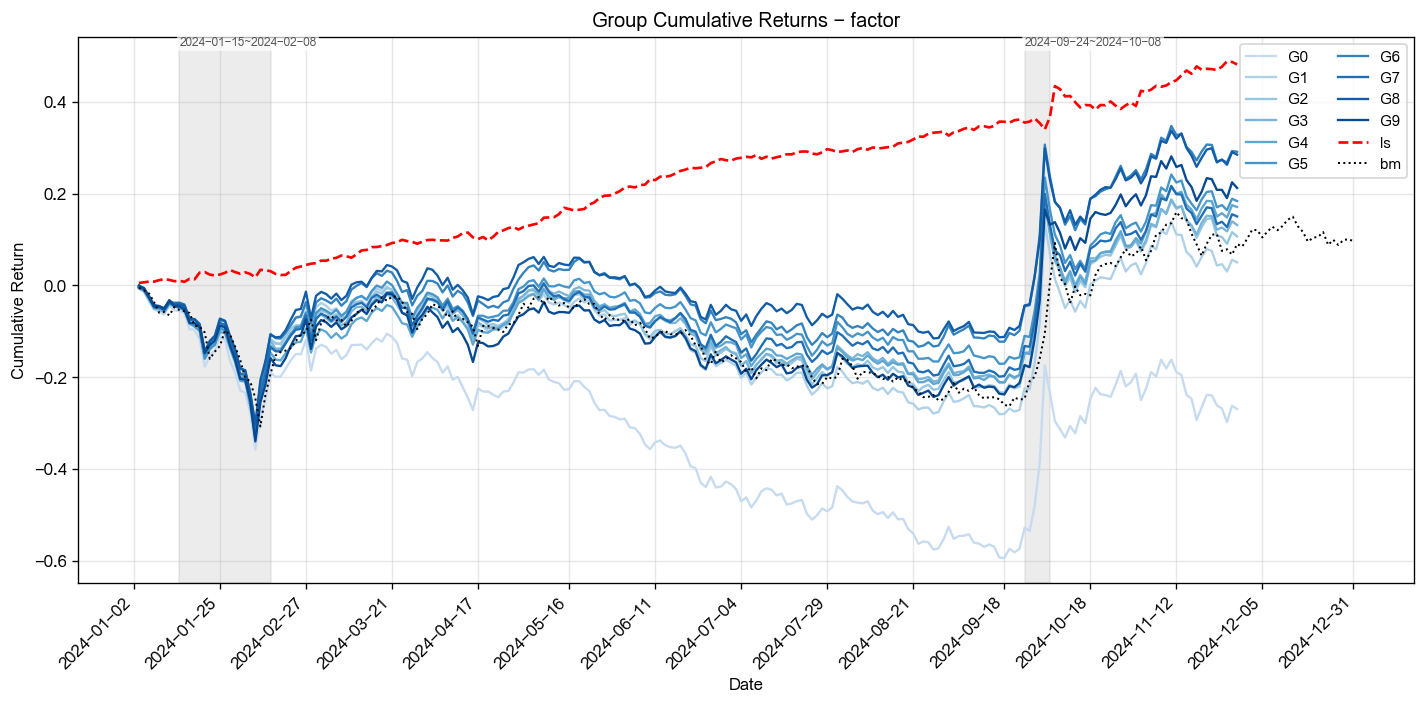
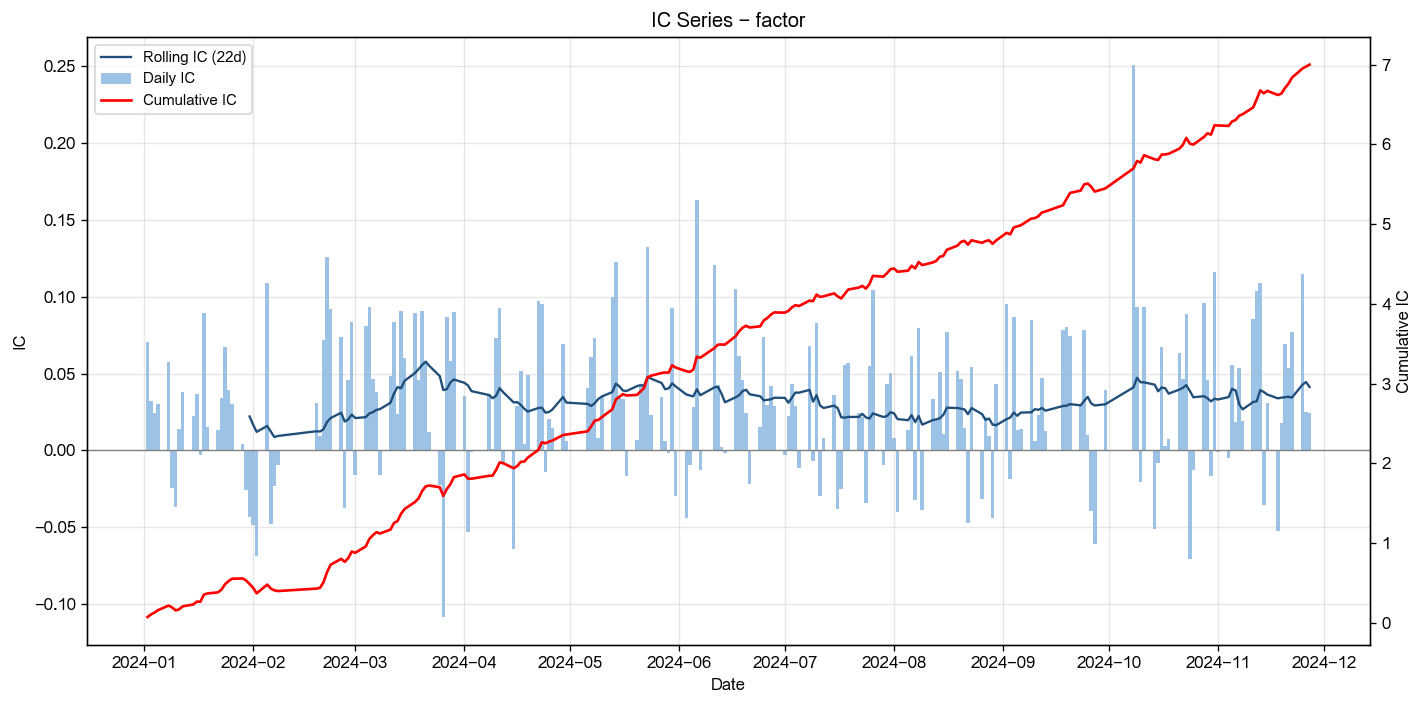
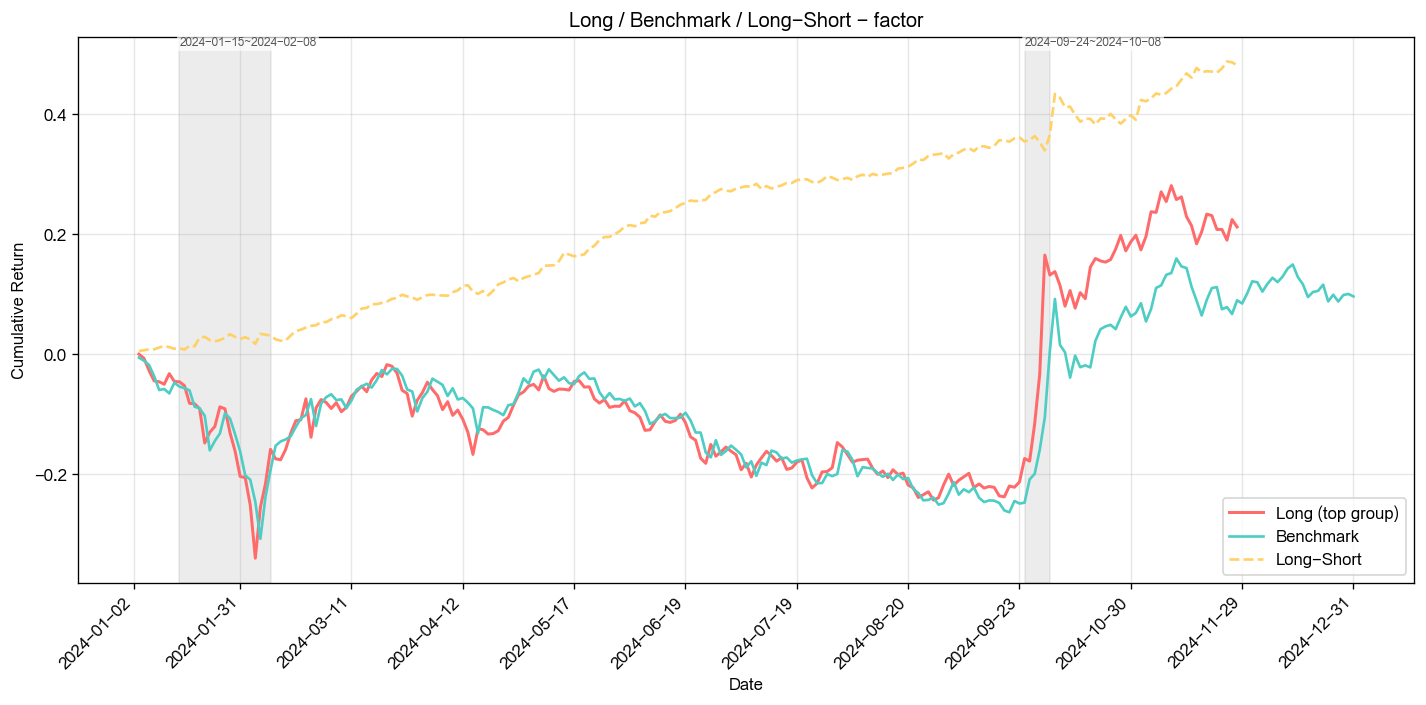
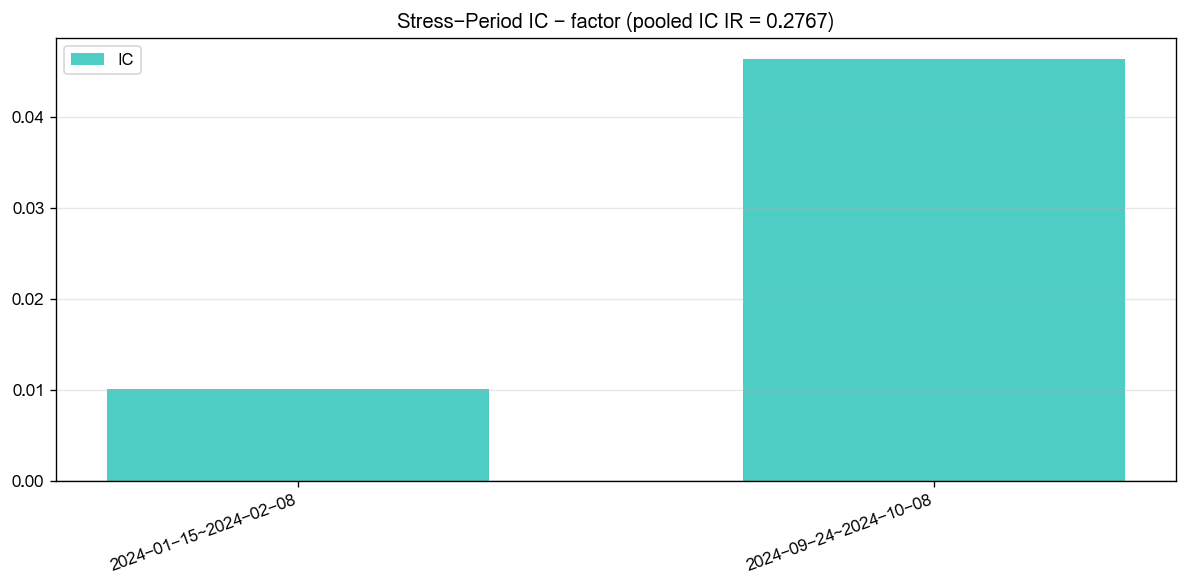
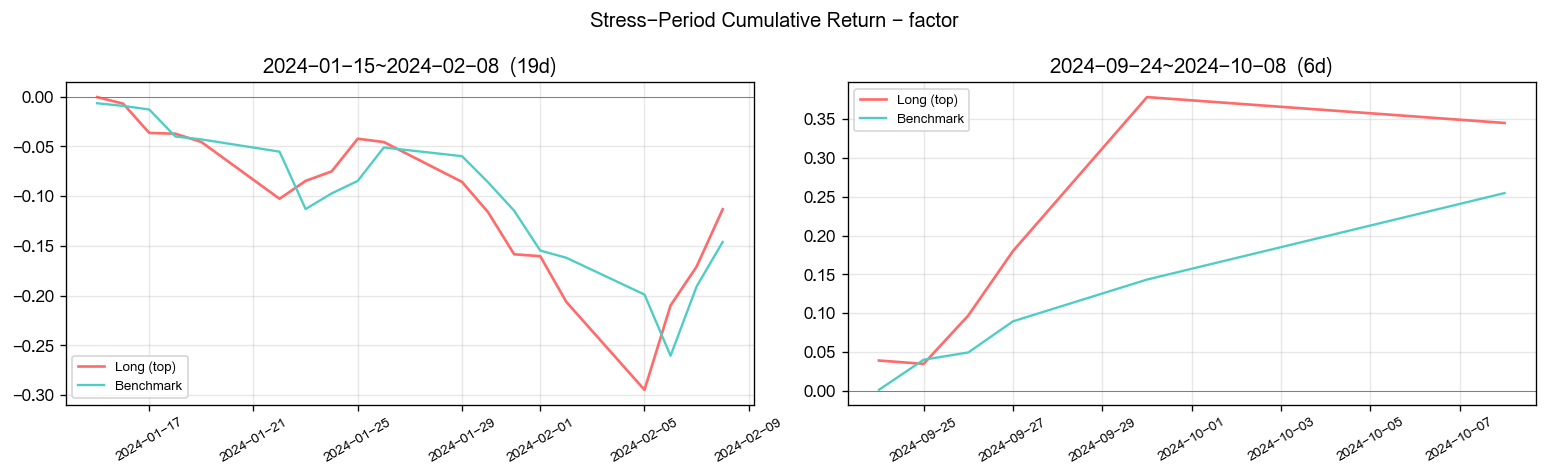

[2026-08-05 22:51:24] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-05 22:51:25] [warning  ] 返回的Outputs实例(size=35281978) 大于 64K, 将不会被缓存
[2026-08-05 22:51:25] [info     ] bigalpha_eval.v4 运行完成 [14.819s].


In [2]:
"""
# Qlib-style ALSTM online inference entry (LSTM recurrent cell).
# Loads uploaded weights for submission inference. Platform training is
# available only through the explicit RUN_PLATFORM_TRAINING opt-in.
"""
import os
import gc
import time
import numpy as np
import pandas as pd
import dai
import torch
import structlog

from lstm_train import (
    MODEL_PATH, BATCH,
    QuantALSTMLSTM, pool, load_model, predict_scores_streaming, _resolve_bar1m_table,
    train_and_save,
)

logger = structlog.get_logger()
# Submission-safe default: public evaluation must load uploaded weights.
# Set RUN_PLATFORM_TRAINING=1 only in an interactive notebook session where
# you intentionally want to run automatic selection and full-data refitting.
RUN_PLATFORM_TRAINING = os.environ.get("RUN_PLATFORM_TRAINING", "0").strip().lower() in {"1", "true", "yes"}


def main(datasources, start_date, end_date):
    table = _resolve_bar1m_table(datasources)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Missing model file: {MODEL_PATH}. Copy the selected full-data checkpoint to lstm_best.json beside this notebook.")

    ckpt = load_model(MODEL_PATH, map_location=device)
    stats = (np.asarray(ckpt["mean"], np.float32), np.asarray(ckpt["std"], np.float32))
    feature_cols = ckpt["feature_cols"]
    if int(ckpt.get("bars_per_day", -1)) != 240 or ckpt.get("bar_frequency") != "1m":
        raise ValueError("lstm_best.json must be a single-frequency 1m/1day checkpoint.")
    if ckpt.get("architecture") != "qlib_style_alstm" or str(ckpt.get("rnn_type", "")).upper() != "LSTM":
        raise ValueError("lstm_best.json is not the Qlib-style ALSTM/LSTM checkpoint required by this notebook.")

    model = QuantALSTMLSTM(**ckpt["model_cfg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    logger.info("loaded ALSTM/LSTM 1m model", path=MODEL_PATH, epoch=ckpt.get("epoch", ckpt.get("selected_epoch")), loss=ckpt.get("loss_name"), n_features=len(feature_cols), device=str(device))

    instruments = pool(start_date, end_date)
    seq_len = int(ckpt.get("seq_len", ckpt["model_cfg"]["seq_len"]))
    idx_df = predict_scores_streaming(
        model, table, start_date, end_date, instruments, stats, feature_cols, device,
        batch_size=BATCH, seq_len=seq_len,
    )
    if idx_df.empty:
        raise ValueError("No inference samples were generated. Check date range, stock pool, and history window.")

    stk = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    stk["date"] = pd.to_datetime(stk["date"]).dt.normalize()
    stk["instrument"] = stk["instrument"].astype(str)
    idx_df["date"] = pd.to_datetime(idx_df["date"]).dt.normalize()
    idx_df["instrument"] = idx_df["instrument"].astype(str)

    result = (
        pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["score"])
        .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
        .reset_index(drop=True)
    )

    logger.info("scores ready", rows=len(result), days=result["date"].nunique(), instruments=result["instrument"].nunique())
    return result


if __name__ == "__main__":
    from bigmodule import M

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}

    # Official-template behavior for an interactive notebook run: train when
    # the checkpoint is absent. RUN_PLATFORM_TRAINING=1 also forces a refit.
    # Public submissions must include lstm_best.json, so they stay inference-only.
    if RUN_PLATFORM_TRAINING or not os.path.exists(MODEL_PATH):
        logger.info("start platform training and automatic selection", path=MODEL_PATH, reason=("forced" if RUN_PLATFORM_TRAINING else "checkpoint_missing"))
        train_and_save(datasources)

    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"

    logger.info("start inference", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    logger.info("start official eval")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
